# EQAO Test Scores Prediction Project

## Project Overview

EQAO is an evidence-based research-informed organization in Ontario, Canada, that is focused on empowering educators, parents, guardians, stakeholders and the public at large with the insights and information needed to support student learning and improve student outcomes. To this end, they administer standardized tests to Grade 3, 6, and 9 in order to evaluate whether students at individual schools are performing to the provincial standard in the following subjects: Reading, Writing, Mathematics.

The main purpose of this project is to use results available **today** to predict whether less than half of the Grade 6 population will achieve the Provincial Mathematics standard **the next year**. This information could be used to help allocate Ministry resources to help the schools most at risk in failing.

Four different machine learning models were trained. The best performing model was found to be a **Random Forest model**, with an true positive rate of 0.739 and a false negative rate of 0.342. This means that the model correctly predicts schools that need help 74% of the time, and incorrectly misses schools that need help 34% of the time.

## Concept Overview

This is a classification problem, where we want to predict the likelihood of a school has a pass rate of less than 50% in Maths. We will call these schools 'high risk schools'. We will therefore create a new target variable called 'High Risk School' and schools with a pass rate less than 50% a value of 1.0 or True and the remaining schools 0 or false.

In this project, the following machine learining algorithms will be used:

- Logistic Regression
  - This algorithm finds the relationship between changes to a given input (features) and the probability of observing a particular outcome
  - It only handles binary outcomes
  - Fairly simple model which is easily interpretable

- K-Nearest Neighbours Classifier
  - This algorithm takes a majority vote of the nearest cluster of points to assign to assign a category to the unknown point
  - K represents the number of neighbours that are looked at for the majority vote
  - It is a very simple model but can be slow with large datasets

- Random Forest Classifier
  - This algorithm takes the majority vote of an ensemble (large group, e.g. hundreds) of Decision Tree Classifiers
  - Each Decision Tree is given a random subset of the overall input training data. This takes one dataset and gives us multiple samples for predicting
  - Each Decision Tree is given a random set of input features to use to make its prediction. This stops any one feature from dominating and encourages independence of each tree

- XGBoost Classifier
  - This algorithm uses an ensemble of Decision Trees in series, rather than in parallel
  - The first decision tree makes a rough guess on the splitting points and then subsequent trees are trained on the errors of the previous tree
  - the final decision is taken as the sum of the odds of all the individual trees

  In all cases, a "threshold value" has to be determined. When this value is exceeded, we interpret the probability as 'True'. As a starting point, this value is usually taken as 0.5. However, since we want to minimize false negatives (i.e. we don't want to miss out on schools that are high risk), we may choose to adjust this threshold as we optimize for the Recall vaue (TP / (TP + FN))



## Data Overview and Preparation

**Data Overview**

The data used for this project was made available through the Ministry of Education as reported by schools, school boards, EQAO and Statistics Canada. This data summarizes the exam results by school and board, combined with select demographic data on each school. The overall datasets can be found at the following link: [School Information and Student Demographics](https://data.ontario.ca/dataset/school-information-and-student-demographics)

The main dataset used was the 2023-2024 dataset. This dataset includes the "Percentage of Grade 6 Students Achieving the Provincial Standard in Mathematics" column which will be used to develop the target variable. The remaining columns will be used as features for model prediction. It should be noted that "Change in Grade 6 Mathematics Achievement Over Three Years" feature includes the current year in the calculation. Therefore, in order to avoid data leakage, we need to use the 2019 to 2022 data to determine the 3 year change. A new feature for the year on year change was also created.

**Data Preparation**

The data preparation steps are outlined as follows:

1. Create individual dataframes for the 2019, 2021, 2022 and 2023 data
2. Create a new dataframe using the 2023 data as a basis
3. Calculate the one year and three year maths performance changes by subtracting the respective dataframes. Strip non-numeric characters and convert to float
3. Drop the 2023 data column for 'achievement over three years' and replace  column using the calculated variable above. Create a similar column for the one year change. Since the two dataframes are different lengths, we have to match the school number.
4. Drop any rows where the Grade 6 Mathematics performance variable is missing
5. Create a new column which determines the percentile performance for each school based on their Grade 6 Mathematics results
6. Create the target variable column by assigning a 1 to any school with a percentile <= 20% and a 0 for all the remaining schools
7. Drop the 2023 data column for 'achievement over three years' and replace with the 2022 column
8. Keep the columns which are useful for prediction: Board Name, School Language, Enrollment, Percentage of Students Who Are New to Canada from a Non-English Speaking Country, Percentage of Students Who Are New to Canada from a Non-French Speaking Country, Percentage of Students Receiving Special Education Services, Percentage of Students Whose First Language Is Not French, Percentage of Students Whose First Language Is Not English, Percentage of Grade 6 Students Achieving the Provincial Standard in Mathematics, Change in Grade 6 Mathematics Achievement Over Three Years, Percentage of School-Aged Children Who Live in Low-Income Households, Percentage of Students Whose Parents Have No Degree, Diploma or Certificate
9. Train-test split at this point so that the test data stays pure
10. Investigate missing values and impute categorical variables with the mode and numerical variables with the median, if needed
11. One Hot encode the categorical variables
12. Use Standard Scaler for the numerical variables







## Application and Code

In [22]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV
import joblib


In [2]:
#Load 2023 EQAO data
filepath_2023 = r"C:\Users\rossi\OneDrive\Data Science Projects\EQAO Test Scores\Data\raw\new_sif_data_table_2023_24prelim_en_january2026.xlsx - SIFprelim23-24_EN.csv"
df_2023 = pd.read_csv(filepath_2023)
df_2023.head()

,Board Number,Board Name,Board Type,School Number,School Name,School Type,School Special Condition Code,School Level,School Language,Grade Range,...,Change in Grade 6 Writing Achievement Over Three Years,Percentage of Grade 6 Students Achieving the Provincial Standard in Mathematics,Change in Grade 6 Mathematics Achievement Over Three Years,Percentage of Grade 9 Students Achieving the Provincial Standard in Mathematics,Change in Grade 9 Mathematics Achievement Over Three Years,Percentage of Students That Passed the Grade 10 OSSLT on Their First Attempt,Change in Grade 10 OSSLT Literacy Achievement Over Three Years,Percentage of School-Aged Children Who Live in Low-Income Households,"Percentage of Students Whose Parents Have No Degree, Diploma or Certificate",Extract Date
0,B28010,Algoma DSB,Pub Dist Sch Brd (E/F),902344,Algoma Education Connection Secondary School,Public,Alternative,Secondary,English,9-12,...,NaN,NaN,NaN,N/D,NaN,N/R,NaN,15%,5%,"Friday, January 02, 2026"
1,B28010,Algoma DSB,Pub Dist Sch Brd (E/F),019186,Anna McCrea Public School,Public,Not applicable,Elementary,English,JK-8,...,23.0,62%,12.0,NaN,NaN,NaN,NaN,0%,0%,"Friday, January 02, 2026"
2,B28010,Algoma DSB,Pub Dist Sch Brd (E/F),043362,Ben R McMullin Public School,Public,Not applicable,Elementary,English,JK-8,...,-5.0,27%,-5.0,NaN,NaN,NaN,NaN,15%,10%,"Friday, January 02, 2026"
3,B28010,Algoma DSB,Pub Dist Sch Brd (E/F),054542,Blind River Public School,Public,Not applicable,Elementary,English,JK-8,...,-8.0,17%,-28.0,NaN,NaN,NaN,NaN,20%,10%,"Friday, January 02, 2026"
4,B28010,Algoma DSB,Pub Dist Sch Brd (E/F),490822,Boreal French Immersion Public School,Public,Not applicable,Elementary,English,JK-8,...,6.0,61%,2.0,NaN,NaN,NaN,NaN,10%,0%,"Friday, January 02, 2026"


In [3]:
#Load 2022 EQAO data
filepath_2022 = r"C:\Users\rossi\OneDrive\Data Science Projects\EQAO Test Scores\Data\raw\sif_data_table_2022_2023_en.xlsx - SIF22-23_EN.csv"
df_2022 = pd.read_csv(filepath_2022)
df_2022.head()

,Board Number,Board Name,Board Type,School Number,School Name,School Type,School Special Condition Code,School Level,School Language,Grade Range,...,Change in Grade 6 Writing Achievement Over Three Years,Percentage of Grade 6 Students Achieving the Provincial Standard in Mathematics,Change in Grade 6 Mathematics Achievement Over Three Years,Percentage of Grade 9 Students Achieving the Provincial Standard in Mathematics,Change in Grade 9 Mathematics Achievement Over Three Years,Percentage of Students That Passed the Grade 10 OSSLT on Their First Attempt,Change in Grade 10 OSSLT Literacy Achievement Over Three Years,Percentage of School-Aged Children Who Live in Low-Income Households,"Percentage of Students Whose Parents Have No Degree, Diploma or Certificate",Extract Date
0,B28010,Algoma DSB,Pub Dist Sch Brd (E/F),902344,Algoma Education Connection Secondary School,Public,Alternative,Secondary,English,9-12,...,NaN,NaN,NaN,N/D,NaN,N/R,NaN,15,5,26-03-2025
1,B28010,Algoma DSB,Pub Dist Sch Brd (E/F),19186,Anna McCrea Public School,Public,Not applicable,Elementary,English,JK-8,...,NaN,45%,NaN,NaN,NaN,NaN,NaN,0,0,26-03-2025
2,B28010,Algoma DSB,Pub Dist Sch Brd (E/F),43362,Ben R McMullin Public School,Public,Not applicable,Elementary,English,JK-8,...,NaN,38%,NaN,NaN,NaN,NaN,NaN,20,10,26-03-2025
3,B28010,Algoma DSB,Pub Dist Sch Brd (E/F),54542,Blind River Public School,Public,Not applicable,Elementary,English,JK-8,...,NaN,29%,NaN,NaN,NaN,NaN,NaN,20,10,26-03-2025
4,B28010,Algoma DSB,Pub Dist Sch Brd (E/F),490822,Boreal French Immersion Public School,Public,Not applicable,Elementary,English,JK-8,...,NaN,54%,NaN,NaN,NaN,NaN,NaN,10,0,26-03-2025


In [4]:
#Load 2021 EQAO data
filepath_2021 = r"C:\Users\rossi\OneDrive\Data Science Projects\EQAO Test Scores\Data\raw\sif_data_table_2021_2022_en.csv"
df_2021 = pd.read_csv(filepath_2021)
df_2021.head()

,Board Number,Board Name,Board Type,School Number,School Name,School Type,School Special Condition Code,School Level,School Language,Grade Range,...,Change in Grade 6 Writing Achievement Over Three Years,Percentage of Grade 6 Students Achieving the Provincial Standard in Mathematics,Change in Grade 6 Mathematics Achievement Over Three Years,Percentage of Grade 9 Students Achieving the Provincial Standard in Mathematics,Change in Grade 9 Mathematics Achievement Over Three Years,Percentage of Students That Passed the Grade 10 OSSLT on Their First Attempt,Change in Grade 10 OSSLT Literacy Achievement Over Three Years,Percentage of School-Aged Children Who Live in Low-Income Households,"Percentage of Students Whose Parents Have No Degree, Diploma or Certificate",Extract Date
0,B28010,Algoma DSB,Pub Dist Sch Brd (E/F),902344,Algoma Education Connection Secondary School,Public,Alternative,Secondary,English,9-12,...,NaN,NaN,NaN,NaN,NaN,N/R,NaN,25,10,26/03/2025
1,B28010,Algoma DSB,Pub Dist Sch Brd (E/F),19186,Anna McCrea Public School,Public,Not applicable,Elementary,English,JK-8,...,NaN,50%,NaN,NaN,NaN,NaN,NaN,10,0,26/03/2025
2,B28010,Algoma DSB,Pub Dist Sch Brd (E/F),43362,Ben R McMullin Public School,Public,Not applicable,Elementary,English,JK-8,...,NaN,32%,NaN,NaN,NaN,NaN,NaN,30,10,26/03/2025
3,B28010,Algoma DSB,Pub Dist Sch Brd (E/F),54542,Blind River Public School,Public,Not applicable,Elementary,English,JK-8,...,NaN,45%,NaN,NaN,NaN,NaN,NaN,25,5,26/03/2025
4,B28010,Algoma DSB,Pub Dist Sch Brd (E/F),490822,Boreal French Immersion Public School,Public,Not applicable,Elementary,English,JK-8,...,NaN,59%,NaN,NaN,NaN,NaN,NaN,20,0,26/03/2025


In [5]:
#Load 2019 EQAO data
filepath_2019 = r"C:\Users\rossi\OneDrive\Data Science Projects\EQAO Test Scores\Data\raw\sif_data_table_2019_2020_en.csv"
df_2019 = pd.read_csv(filepath_2019)
df_2019.head()

,Board Number,Board Name,Board Type,School Number,School Name,School Type,School Special Condition Code,School Level,School Language,Grade Range,...,Change in Grade 6 Mathematics Achievement Over Three Years,Percentage of Grade 9 Students Achieving the Provincial Standard in Academic Mathematics,Change in Grade 9 Academic Mathematics Achievement Over Three Years,Percentage of Grade 9 Students Achieving the Provincial Standard in Applied Mathematics,Change in Grade 9 Applied Mathematics Achievement Over Three Years,Percentage of Students That Passed the Grade 10 OSSLT on Their First Attempt,Change in Grade 10 OSSLT Literacy Achievement Over Three Years,Percentage of School-Aged Children Who Live in Low-Income Households,"Percentage of Students Whose Parents Have No Degree, Diploma or Certificate",Extract Date
0,B28010,Algoma DSB,Pub Dist Sch Brd (E/F),902344,Algoma Education Connection Secondary School,Public,Alternative,Secondary,English,9-12,...,NaN,N/D,NaN,N/R,NaN,N/R,NaN,25,10,4/8/2022
1,B28010,Algoma DSB,Pub Dist Sch Brd (E/F),019186,Anna McCrea Public School,Public,Not applicable,Elementary,English,JK-8,...,-13.0,NaN,NaN,NaN,NaN,NaN,NaN,10,0,4/8/2022
2,B28010,Algoma DSB,Pub Dist Sch Brd (E/F),043362,Ben R McMullin Public School,Public,Not applicable,Elementary,English,JK-8,...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,35,5,4/8/2022
3,B28010,Algoma DSB,Pub Dist Sch Brd (E/F),054542,Blind River Public School,Public,Not applicable,Elementary,English,JK-8,...,-5.0,NaN,NaN,NaN,NaN,NaN,NaN,25,0,4/8/2022
4,B28010,Algoma DSB,Pub Dist Sch Brd (E/F),490822,Boreal French Immersion Public School,Public,Not applicable,Elementary,English,JK-8,...,28.0,NaN,NaN,NaN,NaN,NaN,NaN,20,5,4/8/2022


In [6]:
df_2023.columns

Index(['Board Number', 'Board Name', 'Board Type', 'School Number',
       'School Name', 'School Type', 'School Special Condition Code',
       'School Level', 'School Language', 'Grade Range', 'Building Suite',
       'P.O. Box', 'Street', 'Municipality', 'City', 'Province', 'Postal Code',
       'Phone Number', 'Fax Number', 'School Website', 'Board Website',
       'Enrolment', 'Latitude', 'Longitude',
       'Percentage of Students Whose First Language Is Not English',
       'Percentage of Students Whose First Language Is Not French',
       'Percentage of Students Who Are New to Canada from a Non-English Speaking Country',
       'Percentage of Students Who Are New to Canada from a Non-French Speaking Country',
       'Percentage of Students Receiving Special Education Services',
       'Percentage of Students Identified as Gifted',
       'Percentage of Grade 3 Students Achieving the Provincial Standard in Reading',
       'Change in Grade 3 Reading Achievement Over Three Years

In [7]:
#Calculate the Percentage of Maths Students At Grade by Year

df22 = pd.to_numeric(df_2022.set_index('School Number')['Percentage of Grade 6 Students Achieving the Provincial Standard in Mathematics'].str.replace('%', ''), errors='coerce') #drop percentage symbol from column
df22.dropna(inplace=True) #drop rows with NaN
df22 = df22.astype(float) #recast as float for maths operations
df22.index = df22.index.astype(str)

df21 = pd.to_numeric(df_2021.set_index('School Number')['Percentage of Grade 6 Students Achieving the Provincial Standard in Mathematics'].str.replace('%', ''), errors='coerce') #drop percentage symbol from column
df21.dropna(inplace=True) #drop rows with NaN
df21 = df21.astype(float) #recast as float for maths operations
df21.index = df21.index.astype(str)

df19 = pd.to_numeric(df_2019.set_index('School Number')['Percentage of Grade 6 Students Achieving the Provincial Standard in Mathematics'].str.replace('%', ''), errors='coerce') #drop percentage symbol from column
df19.dropna(inplace=True) #drop rows with NaN
df19 = df19.astype(float) #recast as float for maths operations
df19.index = df19.index.astype(str)

In [8]:
#Calculate most recent annual change and three year change of Maths performance
one_year_diff = df22 - df21
three_year_diff = df22 - df19

# Map all the indices to str so they can be compared
#one_year_diff.index = one_year_diff.index.astype(str)
#three_year_diff.index = three_year_diff.index.astype(str)
df_2023['1 Year Diff'] = df_2023['School Number'].map(one_year_diff)
df_2023['3 Year Diff'] = df_2023['School Number'].map(three_year_diff)



In [9]:
cols_to_keep = ['Board Name', 'School Language',
       'Enrolment',
       'Percentage of Students Whose First Language Is Not English',
       'Percentage of Students Whose First Language Is Not French',
       'Percentage of Students Who Are New to Canada from a Non-English Speaking Country',
       'Percentage of Students Who Are New to Canada from a Non-French Speaking Country',
       'Percentage of Students Receiving Special Education Services',
       'Percentage of Grade 6 Students Achieving the Provincial Standard in Mathematics',
       'Percentage of School-Aged Children Who Live in Low-Income Households',
       'Percentage of Students Whose Parents Have No Degree, Diploma or Certificate', '1 Year Diff', '3 Year Diff']

df_raw = df_2023[cols_to_keep] #initialize raw dataframe with 2023 data

df = df_raw.dropna(subset=['Percentage of Grade 6 Students Achieving the Provincial Standard in Mathematics']) #Drop rows with target variable missing

In [10]:
#Convert numeric rows which are currently strings to floats
cols_to_fix = ['Percentage of Students Whose First Language Is Not English',
       'Percentage of Students Whose First Language Is Not French',
       'Percentage of Students Who Are New to Canada from a Non-English Speaking Country',
       'Percentage of Students Who Are New to Canada from a Non-French Speaking Country',
       'Percentage of Students Receiving Special Education Services',
       'Percentage of Grade 6 Students Achieving the Provincial Standard in Mathematics',
       'Percentage of School-Aged Children Who Live in Low-Income Households',
       'Percentage of Students Whose Parents Have No Degree, Diploma or Certificate']

for col in cols_to_fix:
  df[col] = pd.to_numeric(df[col].astype(str).str.replace('%', '', regex=False), errors='coerce')

C:\Users\rossi\AppData\Local\Temp\ipykernel_11224\124181632.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = pd.to_numeric(df[col].astype(str).str.replace('%', '', regex=False), errors='coerce')
C:\Users\rossi\AppData\Local\Temp\ipykernel_11224\124181632.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = pd.to_numeric(df[col].astype(str).str.replace('%', '', regex=False), errors='coerce')
C:\Users\rossi\AppData\Local\Temp\ipykernel_11224\124181632.py:12: SettingWithCopyWarning: 
A 

In [11]:
df[cols_to_fix] = df[cols_to_fix].astype(float)

C:\Users\rossi\AppData\Local\Temp\ipykernel_11224\1486453897.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[cols_to_fix] = df[cols_to_fix].astype(float)


In [12]:
df['Enrolment'] = pd.to_numeric(df['Enrolment'],errors = 'coerce')

C:\Users\rossi\AppData\Local\Temp\ipykernel_11224\1986724618.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Enrolment'] = pd.to_numeric(df['Enrolment'],errors = 'coerce')


In [13]:
df = df.dropna(subset=['Percentage of Grade 6 Students Achieving the Provincial Standard in Mathematics']) #Drop rows with target variable missing
df['at_risk'] = np.where(df['Percentage of Grade 6 Students Achieving the Provincial Standard in Mathematics'] <= 50, 1, 0)
df = df.drop('Percentage of Grade 6 Students Achieving the Provincial Standard in Mathematics', axis=1)

In [14]:
df.describe()

,Enrolment,Percentage of Students Whose First Language Is Not English,Percentage of Students Whose First Language Is Not French,Percentage of Students Who Are New to Canada from a Non-English Speaking Country,Percentage of Students Who Are New to Canada from a Non-French Speaking Country,Percentage of Students Receiving Special Education Services,Percentage of School-Aged Children Who Live in Low-Income Households,"Percentage of Students Whose Parents Have No Degree, Diploma or Certificate",1 Year Diff,3 Year Diff,at_risk
count,3221.000000,3221.000000,3221.000000,3221.000000,3221.000000,3221.000000,3221.000000,3221.000000,2793.000000,2725.000000,3222.000000
mean,384.365104,20.634586,95.962124,6.264514,6.746352,13.701956,9.009314,4.497361,2.832796,-0.964404,0.541899
std,182.246443,19.794903,13.423297,7.251400,7.615687,6.664961,6.249564,6.102520,15.429000,18.461886,0.498319
min,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-64.000000,-75.000000,0.000000
25%,245.000000,5.000000,100.000000,0.000000,0.000000,10.000000,5.000000,0.000000,-6.000000,-12.000000,0.000000
50%,355.000000,15.000000,100.000000,5.000000,5.000000,11.000000,10.000000,3.000000,3.000000,0.000000,1.000000
75%,495.000000,30.000000,100.000000,10.000000,10.000000,20.000000,10.000000,5.000000,13.000000,11.000000,1.000000
max,1180.000000,100.000000,100.000000,65.000000,60.000000,55.000000,45.000000,70.000000,87.000000,71.000000,1.000000


**Exploratory Data Analysis**

Exploratory Data Analysis will be performed on the training data only, so that the test data is truly unseen until we are evaluating the machine learning models.

First, the training data will be created by splitting the input data set in an 80:20 split. A preprocessing pipeline will be created to handle any missing values in the numeric and categorical features. Numeric features will be imputed with median, and categorical features will be imputed with the mode. The categorical variables will then be one hot encoded, while the numeric variables are scaled using the Standard Scaler.

In [15]:
#Create training and test datasets

X = df.drop('at_risk', axis=1)
y = df['at_risk']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=40)

For EDA, we are going to create the following charts:

1. Pie chart showing distribution of target variable
2. Scatter Plot of at_risk schools vs enrolment numbers
3. At risk vs 3 year difference
4. At risk vs 1 year difference

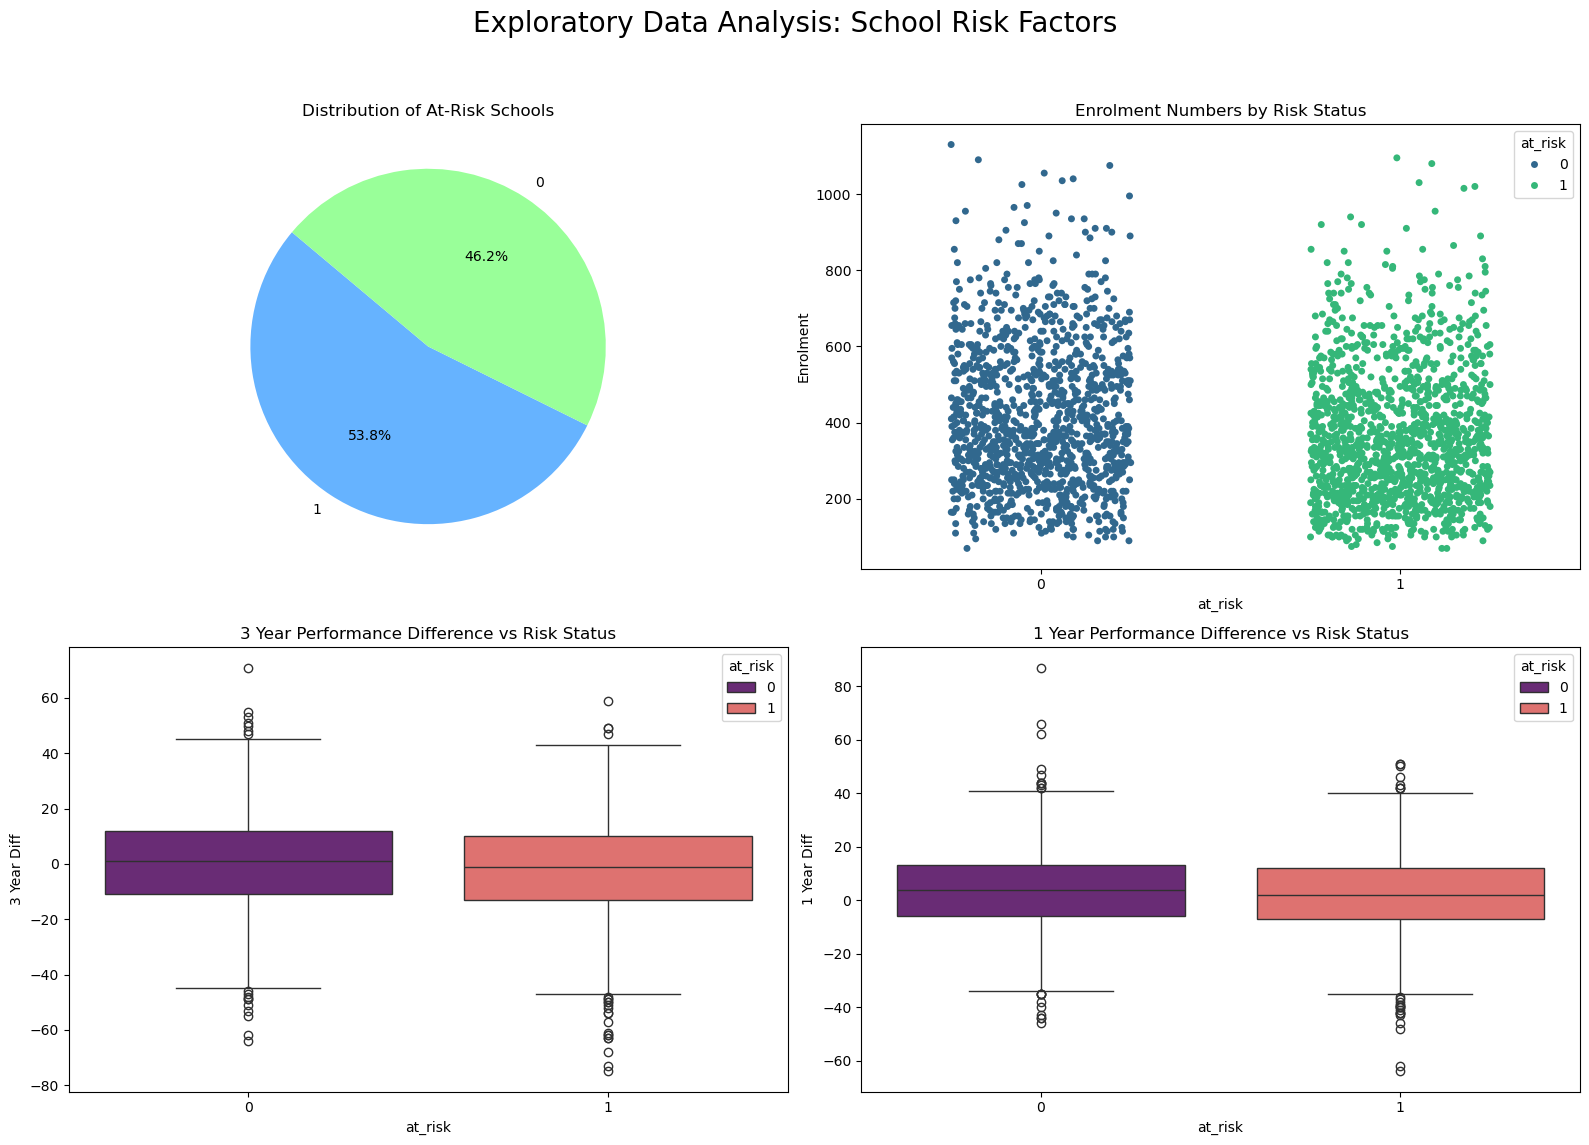

In [16]:
#Exploratory Data Analysis

# 1. Combine into a single dataframe for easier plotting
df_eda = X_train.copy()
df_eda['at_risk'] = y_train

# 2. Initialize the 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Exploratory Data Analysis: School Risk Factors', fontsize=20)

# --- Chart 1: Distribution of Target (Pie Chart) ---
target_counts = df_eda['at_risk'].value_counts()
axes[0, 0].pie(target_counts, labels=target_counts.index, autopct='%1.1f%%', startangle=140, colors=['#66b3ff','#99ff99'])
axes[0, 0].set_title('Distribution of At-Risk Schools')

# --- Chart 2: At-Risk vs Enrolment ---
sns.stripplot(ax=axes[0, 1], data=df_eda, x='at_risk', y='Enrolment', hue='at_risk', palette='viridis', jitter=0.25)
axes[0, 1].set_title('Enrolment Numbers by Risk Status')

# --- Chart 3: At-Risk vs 3 Year Difference ---
sns.boxplot(ax=axes[1, 0], data=df_eda, x='at_risk', y='3 Year Diff', hue='at_risk', palette='magma')
axes[1, 0].set_title('3 Year Performance Difference vs Risk Status')

# --- Chart 4: At-Risk vs 1 Year Difference ---
sns.boxplot(ax=axes[1, 1], data=df_eda, x='at_risk', y='1 Year Diff', hue='at_risk', palette='magma')
axes[1, 1].set_title('1 Year Performance Difference vs Risk Status')

# Adjust layout to prevent overlap
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [17]:
#Pipeline Creation

#Numeric Data
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical Data
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine imputers
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, make_column_selector(dtype_include=['int64', 'float64'])),
        ('cat', categorical_transformer, make_column_selector(dtype_include=['object', 'category']))
    ]
)

#Create pipeline

prep_pipeline = Pipeline(steps=[
        ('preprocessing', preprocessor),
        ])

X_train_transformed = prep_pipeline.fit_transform(X_train)
X_test_transformed = prep_pipeline.transform(X_test)


C:\Users\rossi\anaconda3\envs\ibm_ml\Lib\site-packages\xgboost\training.py:199: UserWarning: [20:43:36] WARNING: D:\bld\xgboost-split_1765326833453\work\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


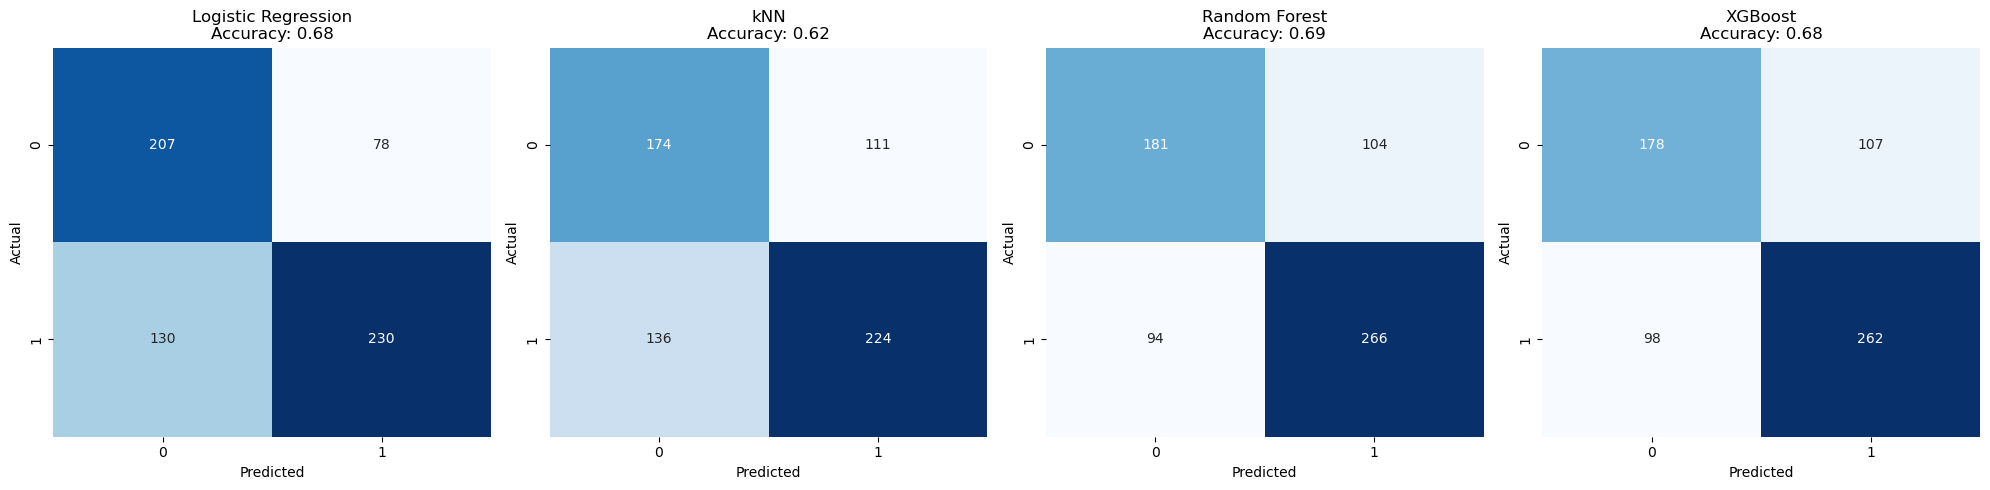

Logistic Regression: 0.6775
kNN: 0.6171
Random Forest: 0.6930
XGBoost: 0.6822


In [18]:
#Model Training and Evaluation

# Initialize Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=100, class_weight='balanced', C = 1.0, random_state=42),
    "kNN": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, use_label_encoder=False, eval_metric='logloss')
}

# Iterate, Train, and Evaluate
results = {}

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, (name, model) in enumerate(models.items()):
    model.fit(X_train_transformed, y_train)
    y_pred = model.predict(X_test_transformed)
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    results[name] = acc

    # Plot Confusion Matrix
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i], cmap='Blues', cbar=False)
    axes[i].set_title(f"{name}\nAccuracy: {acc:.2f}")
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Print Accuracy Summary
for name, score in results.items():
    print(f"{name}: {score:.4f}")

In [19]:
#Perform GridSearchCV on Random Forest Classifier in order to determine the optimal model hyper parameters

# 1. Initialize the base model
rf = RandomForestClassifier(random_state=42, class_weight='balanced')

# 2. Define the grid of parameters to hunt through
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, 25],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

# 3. Set up the Grid Search
# Use 5 folds for cross validation
# scoring='f1' is a more useful parameter than 'accuracy' for risk-based models
grid_search = GridSearchCV(estimator=rf,
                           param_grid=param_grid,
                           cv=5,
                           n_jobs=-1,
                           verbose=2,
                           scoring='f1')

# 4. Fit all models on the train data
grid_search.fit(X_train_transformed, y_train)

# 5. Extract the best results
print(f"Best Parameters: {grid_search.best_params_}")
best_rf = grid_search.best_estimator_

# 6. Final Evaluation on the Test Set
y_pred_final = best_rf.predict(X_test_transformed)
print("\nFinal Model Performance:")
print(classification_report(y_test, y_pred_final))

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Parameters: {'max_depth': 20, 'max_features': 'log2', 'min_samples_split': 5, 'n_estimators': 200}

Final Model Performance:
              precision    recall  f1-score   support

           0       0.63      0.69      0.66       285
           1       0.73      0.68      0.70       360

    accuracy                           0.68       645
   macro avg       0.68      0.68      0.68       645
weighted avg       0.69      0.68      0.68       645



C:\Users\rossi\AppData\Local\Temp\ipykernel_11224\671731891.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='magma')


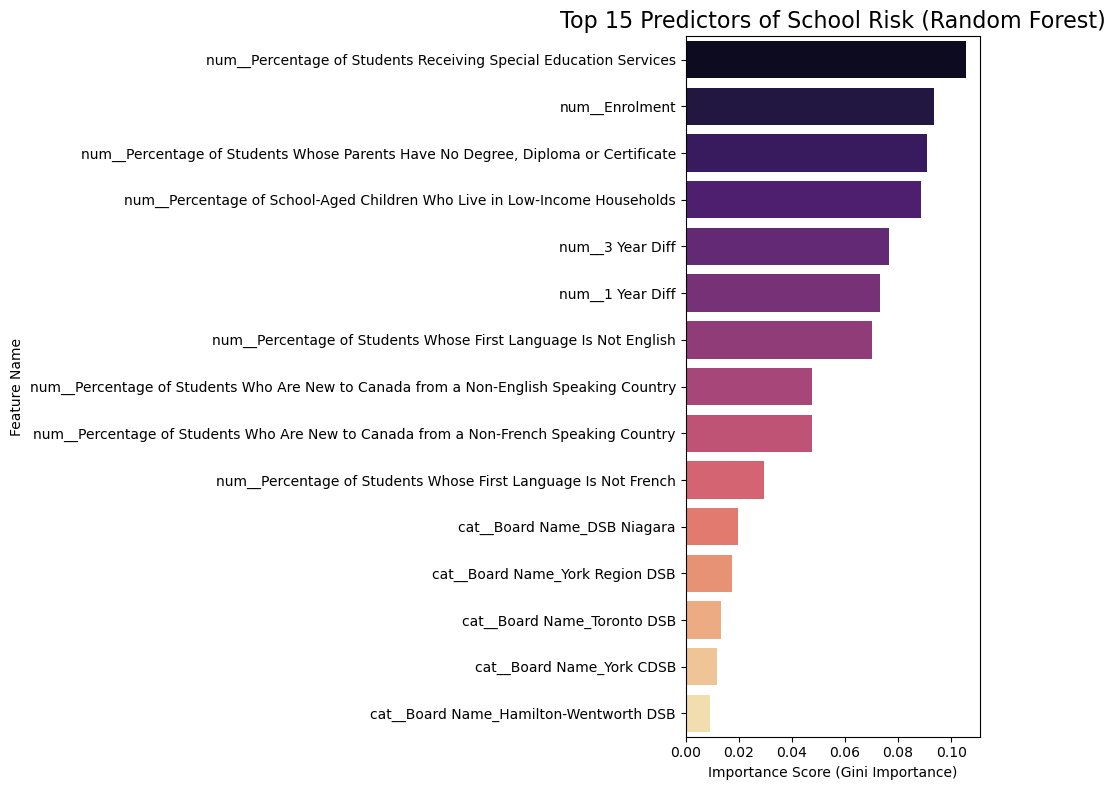

In [20]:
#Determine Feature Importances on the best model

# 1. Get the feature names from the preprocessor
feature_names = prep_pipeline.named_steps['preprocessing'].get_feature_names_out()

# 2. Get importances from the best model found by GridSearchCV
importances = best_rf.feature_importances_

# 3. Create a DataFrame for easy plotting
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 4. Plot the top 15 features for clarity
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='magma')

plt.title('Top 15 Predictors of School Risk (Random Forest)', fontsize=16)
plt.xlabel('Importance Score (Gini Importance)')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

## Results Analysis

The first parameter that should be compared is the accuracy i.e. whether the model correctly predicts the appropriate class. The Random Forest model slightly beat out the XGboost model and the Logistic Regression model. The kNN model performed the worst on this metric.

*   Random Forest - 0.693
*   XG Boost - 0.682
*   Logistic Regression - 0.678
* kNN Classifier - 0.617

For classification projects, however, it is often more important to look at true positive rates and false negative rates as this helps you understand exactly how well the model performed at picking specific classes. We will only compare the Random Forest, XG Boost, and Logistic Regression here since we know the kNN model did not perform as well. The results below show that the Random Forest and XG Boost model perform better at predicting the positive class, i.e. is a school at risk of failing next year's Grade 6 Maths test.

**True Positive Rate**

*   Random Forest - 0.739
*   XG Boost - 0.727
* Logistic Regression - 0.639

---

A similar exercise can be done to determine the false negative rate - i.e how many schools does the model incorrectly miss via its predictions. In this case, the Logistic Regression model performed the best

**False Negative Rate**

*   Random Forest - 0.342
*   XG Boost - 0.355
* Logistic Regression - 0.386

Pulling these two results together, we can calculate the Recall value, where Recall = True Positive / (True Positive + False Negative))

**Recall**

*   Random Forest - 0.684
*   XG Boost - 0.672
* Logistic Regression - 0.623

Therefore overall, the Random Forest model performed the best of the assessed machine learning models.

## Streamlit Export

In [23]:
#Export full Random Forest model

full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', best_rf)
])

joblib.dump(full_pipeline, 'ontario_school_model.pkl')

print("Deployment pipeline saved successfully.")

Deployment pipeline saved successfully.


## Next Steps

In a future extension to this project, the following steps could be taken to take a deeper dive into the data:

*   Vary the threshold for identifying a school as 'at risk' to identify the sweet spot between reducing the number of false negatives and having too many false positives
* Isolate the false negatives to better understand if they have a common characteristic
*   Use SHAP (Shapley Additive Explanations) to better understand why particular schools were flagged as at risk. This goes beyond the feature importance values that were plotted
* Use time-series cross validation across different 3-4 year intervals to assess model stability


